# Imports

In [20]:
import warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# Pegando os dados

In [21]:
df_modelo = pd.read_csv("data/Pilgrim_s_Pride_Corporation_2.csv")
TARGET = "Close"
DATE_COLUMN = "Date"
SEASONAL_PERIOD = 76

df_modelo[DATE_COLUMN] = pd.to_datetime(
    df_modelo[DATE_COLUMN], errors="coerce", utc=True
).dt.tz_localize(None)
df_modelo = df_modelo.dropna(subset=[DATE_COLUMN])
df_modelo = df_modelo.loc[df_modelo[DATE_COLUMN] >= pd.Timestamp("2013-01-01")].copy()
df_modelo = (
    df_modelo.set_index(DATE_COLUMN)
    .sort_index()
    .drop(columns=["Open", "High", "Low", "Volume", "USD_MXN"], errors="ignore")
)
df_escalonado = df_modelo.copy()
print(f"Dados ordenados: {df_modelo.index.is_monotonic_increasing}")

Dados ordenados: True


In [22]:
test_size = int(len(df_modelo) * 0.25)
train_original = df_modelo[TARGET].iloc[:-test_size]
test_original = df_modelo[TARGET].iloc[-test_size:]
train = train_original
test = test_original
print(f"Treino: {len(train)} observações | Teste: {len(test)} observações")

Treino: 2573 observações | Teste: 857 observações


# Buscando o melhor XGBoost

In [26]:
import importlib
import model_utils
importlib.reload(model_utils)

import optuna
import shap
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from model_utils import (
    calculate_metrics,
    evaluate_baselines,
    update_model_result,
    walk_forward_predict,
)

dados = df_modelo.copy()
PERIODO_SAZONAL = 76
WALK_FORWARD_STEP = 50
colunas_features = [coluna for coluna in dados.columns if coluna not in [TARGET, DATE_COLUMN]]
historico = dados[colunas_features + [TARGET]].shift(1)
X = pd.DataFrame(index=dados.index)

periodos_lag = [1, 2, 3, 7, 14, 30, PERIODO_SAZONAL, 2 * PERIODO_SAZONAL]
for coluna in historico.columns:
    for periodo in periodos_lag:
        X[f"{coluna}_lag_{periodo}"] = historico[coluna].shift(periodo - 1)

for coluna in historico.columns:
    X[f"{coluna}_delta_1"] = historico[coluna] - historico[coluna].shift(1)
    X[f"{coluna}_delta_sazonal"] = historico[coluna] - historico[coluna].shift(PERIODO_SAZONAL - 1)

for janela in [3, 7, 14, 30, PERIODO_SAZONAL]:
    for coluna in historico.columns:
        serie = historico[coluna]
        X[f"{coluna}_media_{janela}"] = serie.rolling(janela).mean()
        X[f"{coluna}_desvio_{janela}"] = serie.rolling(janela).std()

alvo_historico = historico[TARGET]
X[f"{TARGET}_delta_3"] = alvo_historico - alvo_historico.shift(3)
X[f"{TARGET}_delta_7"] = alvo_historico - alvo_historico.shift(7)
X[f"{TARGET}_delta_30"] = alvo_historico - alvo_historico.shift(30)
X[f"{TARGET}_media_sazonal"] = alvo_historico.rolling(PERIODO_SAZONAL).mean()
X[f"{TARGET}_desvio_sazonal"] = alvo_historico.rolling(PERIODO_SAZONAL).std()

y = dados[TARGET]
base_modelo = pd.concat([X, y], axis=1).dropna()
X = base_modelo.drop(columns=[TARGET])
y = base_modelo[TARGET]

h_modelo = int(len(X) * 0.25)
X_train = X.iloc[:-h_modelo]
X_test = X.iloc[-h_modelo:]
y_train = y.iloc[:-h_modelo]
y_test = y.iloc[-h_modelo:]
tscv = TimeSeriesSplit(n_splits=5)

def objetivo(trial):
    modelo = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 800),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        objective="reg:squarederror", eval_metric="mae", random_state=42, n_jobs=-1
    )
    erros = []
    for treino_idx, validacao_idx in tscv.split(X_train):
        modelo.fit(X_train.iloc[treino_idx], y_train.iloc[treino_idx])
        previsoes = modelo.predict(X_train.iloc[validacao_idx])
        erros.append(mean_absolute_error(y_train.iloc[validacao_idx], previsoes))
    return np.mean(erros)

estudo = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
estudo.optimize(objetivo, n_trials=50, show_progress_bar=True)

modelo_factory = lambda: XGBRegressor(
    **estudo.best_params,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1
)
melhor_modelo = modelo_factory()
melhor_modelo.fit(X_train, y_train)
previsoes_teste = walk_forward_predict(
    modelo_factory, X_train, y_train, X_test, y_test, step=WALK_FORWARD_STEP
)
metrics_xgb = calculate_metrics(y_test, previsoes_teste)
baselines_xgb = evaluate_baselines(train_original, test_original, PERIODO_SAZONAL)

print("Quantidade de features:", X.shape[1])
print("Walk-forward: refit a cada", WALK_FORWARD_STEP, "observações")
print("Melhores parâmetros:", estudo.best_params)
print("Métricas XGBoost walk-forward:", metrics_xgb)
print("Baselines:", baselines_xgb)

[I 2026-10-04 12:04:26,092] A new study created in memory with name: no-name-4e4349b4-99ae-4582-adf3-31b9d037e785
Best trial: 0. Best value: 0.754191:   2%|▏         | 1/50 [00:24<19:56, 24.42s/it]

[I 2026-10-04 12:04:50,511] Trial 0 finished with value: 0.7541906645238899 and parameters: {'n_estimators': 362, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 0.7541906645238899.


Best trial: 1. Best value: 0.67429:   4%|▍         | 2/50 [00:59<24:40, 30.84s/it] 

[I 2026-10-04 12:05:25,842] Trial 1 finished with value: 0.6742898929050882 and parameters: {'n_estimators': 521, 'max_depth': 12, 'learning_rate': 0.010725209743171996, 'min_child_weight': 10, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is trial 1 with value: 0.6742898929050882.


Best trial: 1. Best value: 0.67429:   6%|▌         | 3/50 [01:18<19:40, 25.12s/it]

...

[I 2026-10-04 12:19:38,308] Trial 47 finished with value: 0.6411960455531188 and parameters: {'n_estimators': 356, 'max_depth': 13, 'learning_rate': 0.012630771877516694, 'min_child_weight': 10, 'subsample': 0.6289134318144232, 'colsample_bytree': 0.9731602722177879, 'reg_alpha': 5.1798868082594133e-08, 'reg_lambda': 5.8723154036610744e-05}. Best is trial 16 with value: 0.6321074937460305.


Best trial: 16. Best value: 0.632107:  98%|█████████▊| 49/50 [15:36<00:23, 23.10s/it]

[I 2026-10-04 12:20:02,749] Trial 48 finished with value: 0.6505002845401083 and parameters: {'n_estimators': 394, 'max_depth': 14, 'learning_rate': 0.01124565275772568, 'min_child_weight': 9, 'subsample': 0.636004327304358, 'colsample_bytree': 0.9773675277556538, 'reg_alpha': 5.16062598690651e-07, 'reg_lambda': 0.00013977019873028657}. Best is trial 16 with value: 0.6321074937460305.


Best trial: 16. Best value: 0.632107: 100%|██████████| 50/50 [16:01<00:00, 19.24s/it]


[I 2026-10-04 12:20:28,021] Trial 49 finished with value: 0.6343467221214087 and parameters: {'n_estimators': 515, 'max_depth': 13, 'learning_rate': 0.011825306656543027, 'min_child_weight': 10, 'subsample': 0.6451536489936355, 'colsample_bytree': 0.8616945879268871, 'reg_alpha': 7.711200428483261e-08, 'reg_lambda': 0.7727454598014012}. Best is trial 16 with value: 0.6321074937460305.
Quantidade de features: 85
Walk-forward: refit a cada 50 observações
Melhores parâmetros: {'n_estimators': 307, 'max_depth': 15, 'learning_rate': 0.015605380298008915, 'min_child_weight': 10, 'subsample': 0.6041226124261373, 'colsample_bytree': 0.9967066056400297, 'reg_alpha': 2.6824337998566902e-06, 'reg_lambda': 0.00010709630746603446}
Métricas XGBoost walk-forward: {'mae': 1.3469759108537949, 'rmse': 2.094418766216836, 'mape': 3.609410267509925, 'smape': 3.6962009779079326, 'wape': 3.8702944474235466}
Baselines: {'naive': {'mae': 15.032457984830806, 'rmse': 17.409610930895454, 'mape': 39.64374563995913

## Análise de resíduos e feature importance

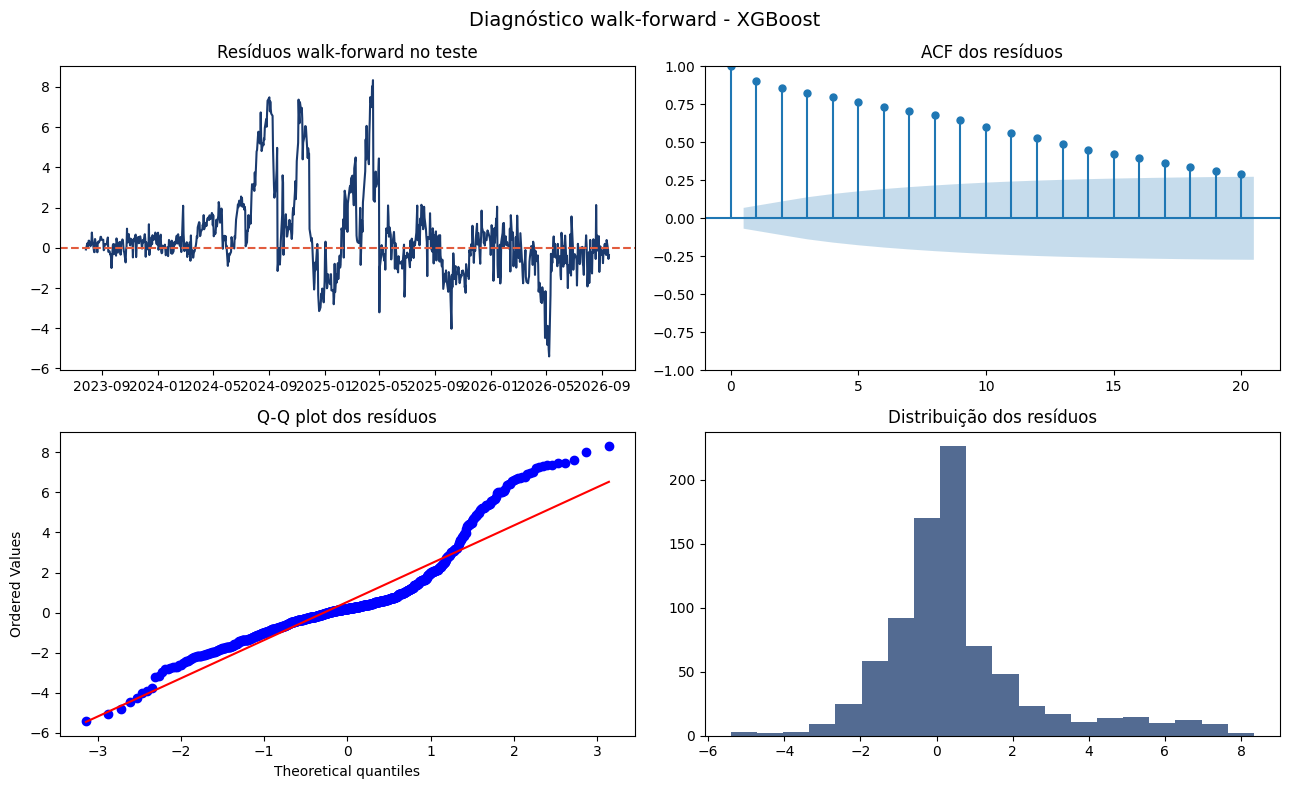

Métricas walk-forward: {'mae': 1.3469759108537949, 'rmse': 2.094418766216836, 'mape': 3.609410267509925, 'smape': 3.6962009779079326, 'wape': 3.8702944474235466}


,lb_stat,lb_pvalue
1,666.3071,0.0
2,1268.5893,0.0
3,1829.4870,0.0
4,2354.3805,0.0
5,2840.3058,0.0
6,3287.5622,0.0
7,3700.2938,0.0
8,4086.9073,0.0
9,4437.6791,0.0
10,4740.6545,0.0


Importância SHAP do XGBoost:


,mean_abs_shap
Close_lag_1,4.948402
Close_media_3,0.405854
Close_lag_2,0.277019
CALM_Close_delta_sazonal,0.068713
Close_lag_3,0.067210
Close_media_7,0.047621
TSN_Close_lag_14,0.035954
Close_media_14,0.034446
Close_lag_7,0.021811
Close_delta_30,0.020538


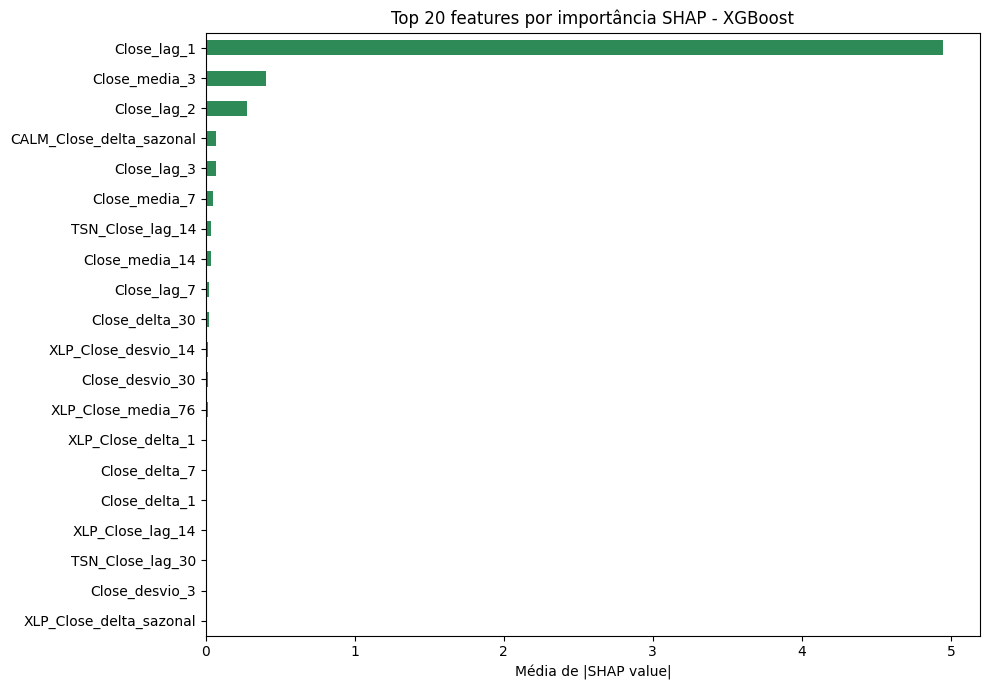

In [27]:
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos_teste = pd.Series(
    y_test.to_numpy() - previsoes_teste,
    index=y_test.index,
    name="residuo"
).dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(residuos_teste.index, residuos_teste, color="#1a3a6e")
axes[0, 0].axhline(0, color="#e25c3e", linestyle="--")
axes[0, 0].set_title("Resíduos walk-forward no teste")
plot_acf(residuos_teste, lags=min(20, len(residuos_teste) - 2), ax=axes[0, 1], title="ACF dos resíduos")
stats.probplot(residuos_teste, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q plot dos resíduos")
axes[1, 1].hist(residuos_teste, bins=20, color="#1a3a6e", alpha=0.75)
axes[1, 1].set_title("Distribuição dos resíduos")
plt.suptitle("Diagnóstico walk-forward - XGBoost", fontsize=14)
plt.tight_layout()
plt.show()

lags_ljung = min(12, len(residuos_teste) // 5)
ljung_box = acorr_ljungbox(residuos_teste, lags=lags_ljung, return_df=True)
print("Métricas walk-forward:", metrics_xgb)
display(ljung_box[["lb_stat", "lb_pvalue"]].round(4))

amostra_shap = X_test.iloc[:min(300, len(X_test))]
explainer_shap = shap.TreeExplainer(melhor_modelo)
shap_values = explainer_shap(amostra_shap)
importancias_shap_xgb = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=amostra_shap.columns
).sort_values(ascending=False)
print("Importância SHAP do XGBoost:")
display(importancias_shap_xgb.head(20).rename("mean_abs_shap").to_frame())

plt.figure(figsize=(10, 7))
importancias_shap_xgb.head(20).sort_values().plot(kind="barh", color="#2e8b57")
plt.title("Top 20 features por importância SHAP - XGBoost")
plt.xlabel("Média de |SHAP value|")
plt.tight_layout()
plt.show()

In [ ]:
melhores_params = estudo.best_params
MAE_FINAL = metrics_xgb["mae"]

In [17]:
print("Melhores params:", melhores_params)
print("MAE final:", MAE_FINAL)

Melhores params: {'n_estimators': 134, 'max_depth': 3, 'learning_rate': 0.011665770945187934, 'min_child_weight': 5, 'subsample': 0.733399811307749, 'colsample_bytree': 0.8150480253950622, 'reg_alpha': 7.4063597007016755, 'reg_lambda': 0.06898507329588001}
MAE final: 0.9474804062213505


In [28]:
resultado_xgb = update_model_result(
    "all_modelos.json",
    "XGBoost",
    metrics_xgb,
    params=estudo.best_params,
    extra={
        "baselines": baselines_xgb,
        "n_features": int(X.shape[1]),
        "walk_forward_step": WALK_FORWARD_STEP,
        "shap_importance": importancias_shap_xgb.head(20).to_dict()
    }
)
print(resultado_xgb)

{'modelo': 'XGBoost', 'mae': 1.3469759108537949, 'rmse': 2.094418766216836, 'mape': 3.609410267509925, 'smape': 3.6962009779079326, 'wape': 3.8702944474235466, 'params': {'n_estimators': 307, 'max_depth': 15, 'learning_rate': 0.015605380298008915, 'min_child_weight': 10, 'subsample': 0.6041226124261373, 'colsample_bytree': 0.9967066056400297, 'reg_alpha': 2.6824337998566902e-06, 'reg_lambda': 0.00010709630746603446}, 'baselines': {'naive': {'mae': 15.032457984830806, 'rmse': 17.409610930895454, 'mape': 39.643745639959135, 'smape': 52.23992173142592, 'wape': 44.06902675458048}, 'seasonal_naive': {'mae': 14.688274061843641, 'rmse': 17.06490497779233, 'mape': 38.70747756294008, 'smape': 50.6694518891883, 'wape': 43.060020075438345}}, 'n_features': 85, 'walk_forward_step': 50, 'shap_importance': {'Close_lag_1': 4.948401927947998, 'Close_media_3': 0.40585383772850037, 'Close_lag_2': 0.2770187258720398, 'CALM_Close_delta_sazonal': 0.0687129944562912, 'Close_lag_3': 0.06721027940511703, 'Clos